# edge ids — model training & evaluation
live notebook: traffic features → attack class (`normal / scan / flood / bruteforce / slowloris`).
steps: explore data · epoch sweep · full-core grid search · confusion matrix.

In [1]:
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score)
import warnings; warnings.filterwarnings('ignore')

df = pd.read_csv('dataset.csv')
FEATURES = ['pkts','ports','syns','top_port','held','nic_pps']
print(df['label'].value_counts())
df.head()

label
slowloris     23
flood         11
normal        10
scan          10
bruteforce     9
Name: count, dtype: int64


,ts,src,pkts,ports,syns,top_port,held,nic_pps,label
0,1789813716,10.42.0.1,13,2,1,1,0,12,normal
1,1789813717,10.42.0.1,19,3,2,2,0,5,normal
2,1789813718,10.42.0.1,25,3,3,3,0,5,normal
3,1789813719,10.42.0.1,31,3,4,4,0,5,normal
4,1789813720,10.42.0.1,37,3,5,5,0,5,normal


## per-class feature signature (why the classes are separable)

In [2]:
df.groupby('label')[FEATURES].mean().round(1)

,pkts,ports,syns,top_port,held,nic_pps
label,,,,,,
bruteforce,95.0,2.0,27.8,27.8,2.0,55.9
flood,48.3,2.4,0.1,0.1,0.1,64358.1
normal,27.5,2.5,4.0,4.0,0.0,5.7
scan,82.4,47.0,61.8,1.7,2.1,305.0
slowloris,13.8,1.0,5.4,5.4,16.3,5.8


## prepare + split (scaled features, stratified 70/30)

In [3]:
X = df[FEATURES].to_numpy(dtype=float)
y = df['label'].astype(str).to_numpy()      # plain numpy (works w/ or w/o pyarrow)
classes = np.unique(y)
scaler = StandardScaler().fit(X)
Xs = scaler.transform(X)
Xtr, Xte, ytr, yte = train_test_split(Xs, y, test_size=0.3, stratify=y, random_state=0)
print('train', Xtr.shape, ' test', Xte.shape)

train (44, 6)  test (19, 6)


## epoch sweep — accuracy vs epochs (different epochs, different accuracy)

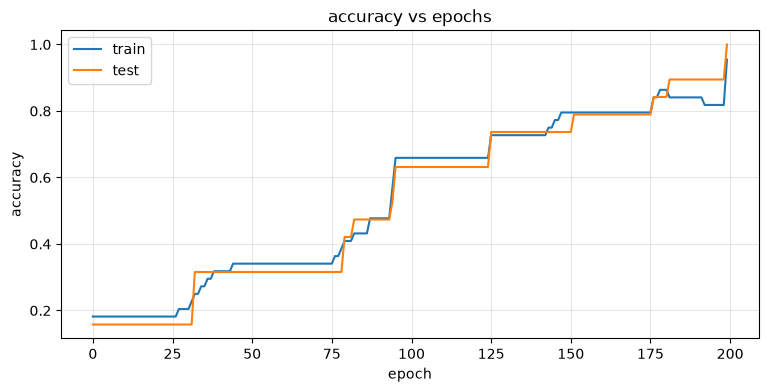

final test accuracy: 1.0


In [4]:
clf = MLPClassifier(hidden_layer_sizes=(16,), random_state=0)
tr_acc, te_acc = [], []
for e in range(200):
    clf.partial_fit(Xtr, ytr, classes=classes)
    tr_acc.append(accuracy_score(ytr, clf.predict(Xtr)))
    te_acc.append(accuracy_score(yte, clf.predict(Xte)))
plt.figure(figsize=(9,4))
plt.plot(tr_acc, label='train'); plt.plot(te_acc, label='test')
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.grid(alpha=.3)
plt.title('accuracy vs epochs'); plt.show()
print('final test accuracy:', round(te_acc[-1], 3))

## full-power grid search (uses all cpu cores: `n_jobs=-1`)

In [5]:
grid = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=0),
    {'hidden_layer_sizes': [(8,), (16,), (32,), (16,16)],
     'alpha': [1e-4, 1e-3, 1e-2],
     'activation': ['relu','tanh']},
    cv=3, n_jobs=-1, scoring='accuracy')
grid.fit(Xtr, ytr)
print('best params:', grid.best_params_)
print('best cv accuracy:', round(grid.best_score_, 3))
best = grid.best_estimator_

best params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (16,)}
best cv accuracy: 0.956


## evaluation — classification report + confusion matrix

              precision    recall  f1-score   support

  bruteforce       1.00      1.00      1.00         3
       flood       1.00      1.00      1.00         3
      normal       1.00      1.00      1.00         3
        scan       1.00      1.00      1.00         3
   slowloris       1.00      1.00      1.00         7

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



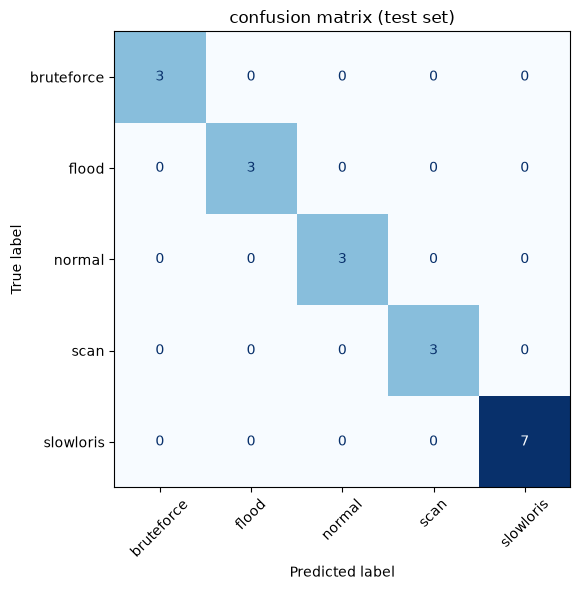

In [6]:
pred = best.predict(Xte)
print(classification_report(yte, pred))
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay(confusion_matrix(yte, pred, labels=classes),
    display_labels=classes).plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('confusion matrix (test set)'); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

## save the trained model

In [7]:
import joblib
joblib.dump({'model': best, 'scaler': scaler, 'features': FEATURES,
             'classes': list(classes)}, 'ids_model.joblib')
print('saved ids_model.joblib')

saved ids_model.joblib


## next: int8 quantization for the board
this notebook runs on python 3.14 (sklearn). the int8 **tflite** export needs a
tensorflow-compatible python (3.11/3.12). options: a 3.12 env for tflite, or a
manual numpy int8 quantization that runs on the board's `tflite_runtime`/numpy.
**record more rows per class first** — 63 rows makes the metrics thin.